### Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

In [39]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score as ras
from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
import warnings
warnings.filterwarnings('ignore')

### Step 2: Read Data

In [4]:
data = pd.read_csv('./data/new_data.csv')

In [5]:
data = data.drop(['isFlaggedFraud'], axis=1)

In [6]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 485.4+ MB


In [8]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00


### Step 3: Data Visualization

In [9]:
typeDic = defaultdict(int)
for col in data.columns:
    if data[col].dtype == np.int64:
        typeDic['int'] += 1
    elif data[col].dtype == np.float_:
        typeDic['float'] += 1
    else:
        typeDic['categorical'] += 1

In [10]:
typeDic

defaultdict(int, {'int': 2, 'categorical': 3, 'float': 5})

<Axes: xlabel='type', ylabel='count'>

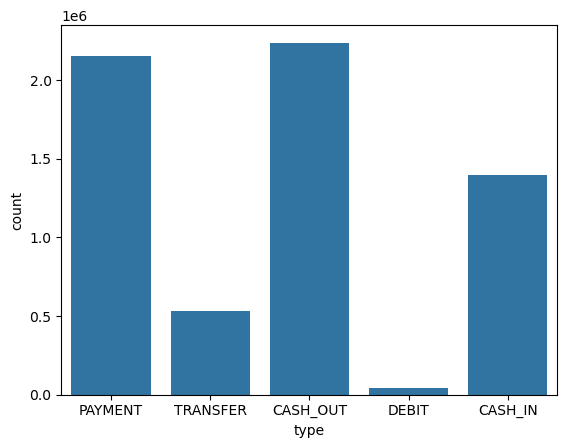

In [11]:
sns.countplot(data, x='type')

<Axes: xlabel='type', ylabel='amount'>

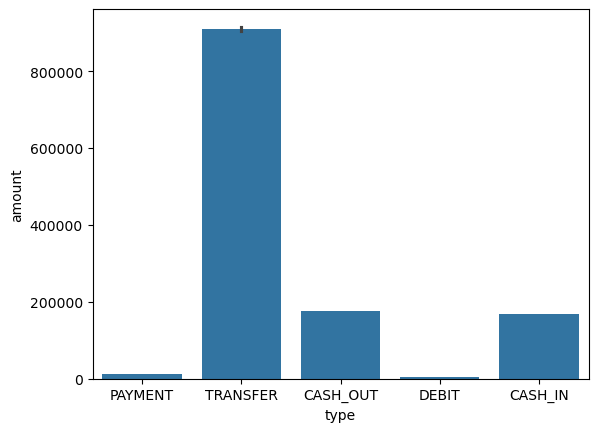

In [12]:
sns.barplot(data, x='type', y='amount') # 先按照x分组，在计算y的平均值

In [13]:
data['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

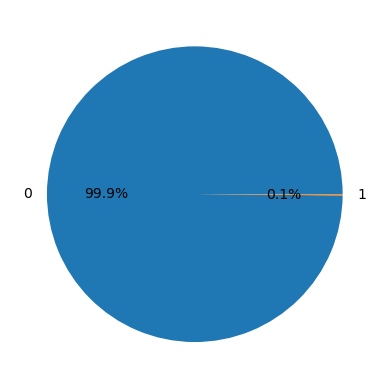

In [14]:
_ = plt.pie(data['isFraud'].value_counts().values, labels=[0, 1], autopct='%1.1f%%')

<Axes: xlabel='step', ylabel='Density'>

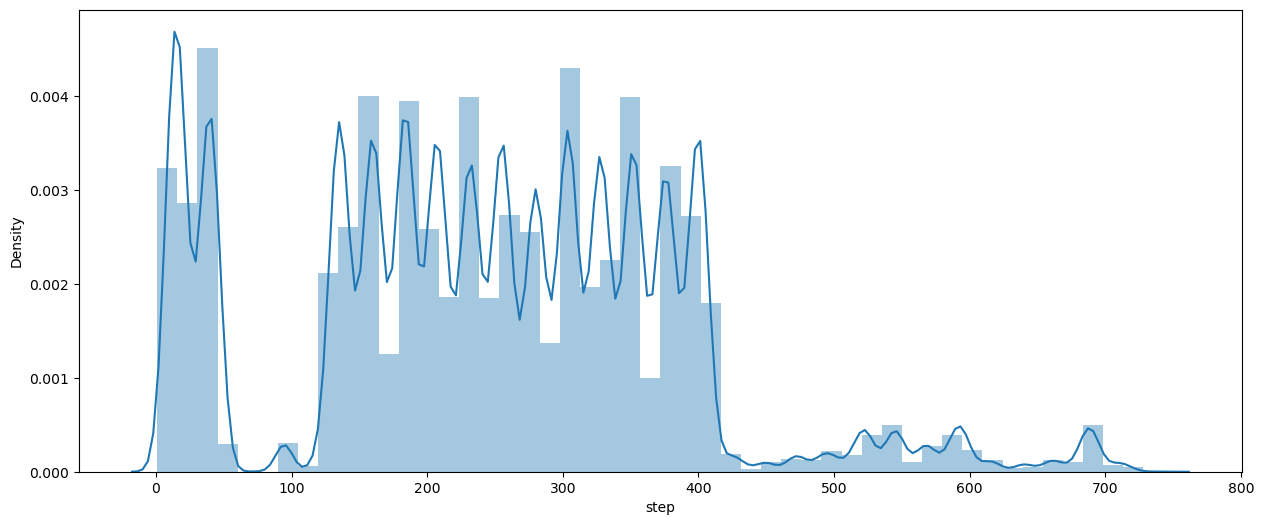

In [15]:
plt.figure(figsize=(15, 6))
sns.distplot(data['step'], bins=50)

<Axes: >

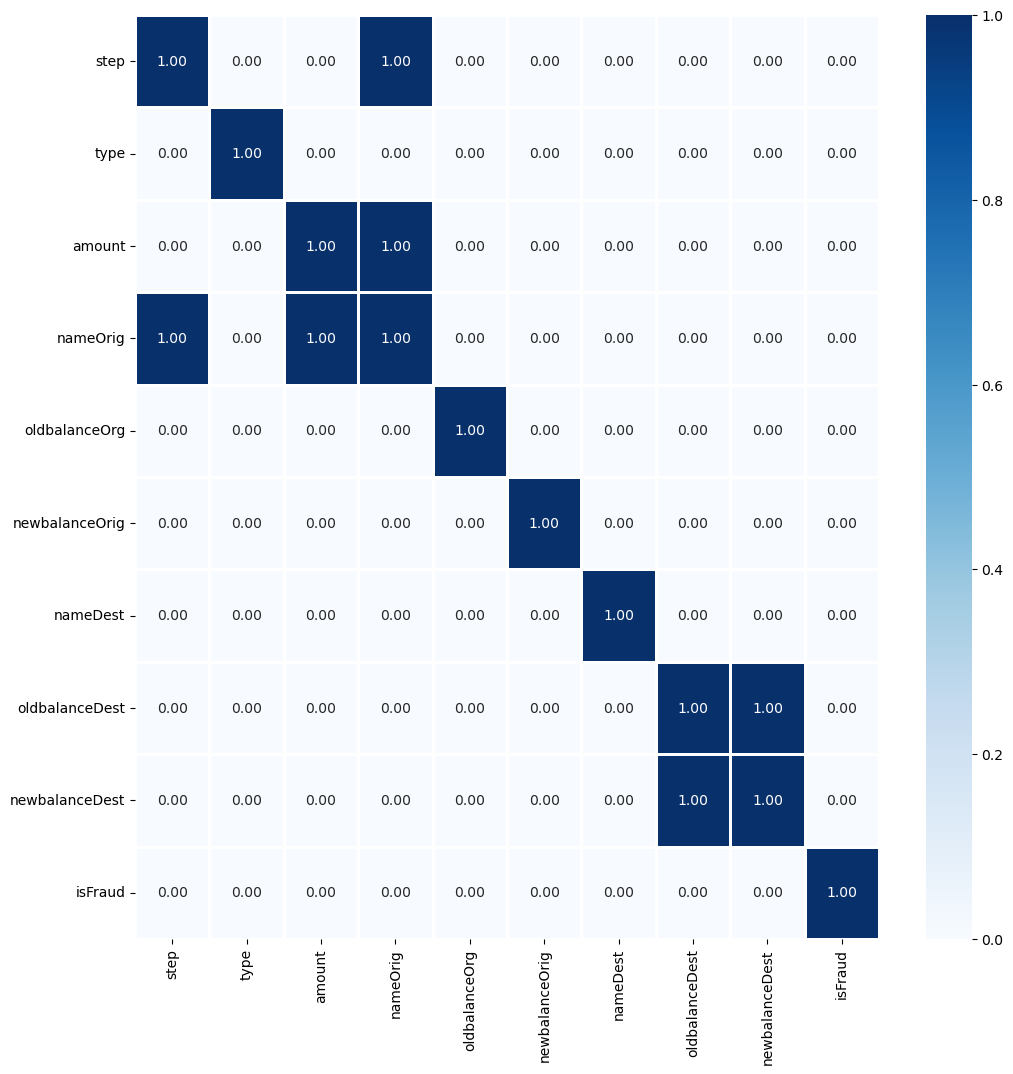

In [22]:
plt.figure(figsize=(12, 12))
sns.heatmap(
    data.apply(lambda x: pd.factorize(x)[0]).corr() > 0.81,
    cmap=plt.cm.Blues,
    fmt='.2f',
    linewidths=2,
    annot=True
)

### Step 4: Data Preprocessing

In [23]:
type_new = pd.get_dummies(data['type'], drop_first=True)
data_new = pd.concat([data, type_new], axis=1)

In [24]:
data_new.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,CASH_OUT,DEBIT,PAYMENT,TRANSFER
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,False,False,True,False
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,False,False,True,False
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,False,False,False,True
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,True,False,False,False
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,False,False,True,False


In [26]:
X = data_new.drop(['isFraud', 'type', 'nameOrig', 'nameDest'], axis=1)
y = data_new['isFraud']

In [28]:
X.shape

(6362620, 10)

In [29]:
y.shape

(6362620,)

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

### Step 5: Model Training

In [37]:
models = [LogisticRegression(), XGBClassifier(), RandomForestClassifier(n_estimators=7, criterion='entropy', random_state=7)]

In [38]:
for model in models:
    model.fit(X_train, y_train)
    print(model)
    train_preds = model.predict_proba(X_train)[:, 1]
    print('Training Accuracy:', ras(y_train, train_preds))
    y_preds = model.predict_proba(X_test)[:, 1]
    print('Test Accuracy:', ras(y_test, y_preds))
    print('---------------')

LogisticRegression()
Training Accuracy: 0.88775339480789
Test Accuracy: 0.8853494917314305
---------------
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)
Training Accuracy: 0.7078356072170395
Test Accuracy: 0.7124525368938691
---------------
RandomForestClassifier(criterion='entropy', 

### Step 6: Model Evaluation

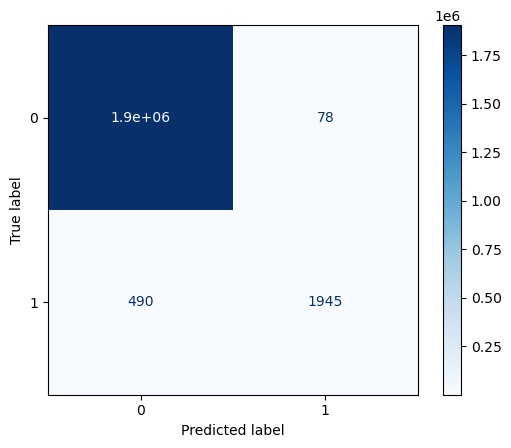

In [42]:
cm = ConfusionMatrixDisplay.from_estimator(models[2], X_test, y_test, cmap=plt.cm.Blues)